In [6]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/rawennedasilvaleite/efficientnet-pathmnist/efficientnet_b0_ft.pth


In [9]:
# ============================================================
# ETAPA 5 — BLOCO 1: Setup, carregar EfficientNet e dados de TESTE
# ============================================================
!pip install medmnist -q

import numpy as np, torch, torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from medmnist import PathMNIST
import os

np.random.seed(42); torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
ARQ = "/root/.medmnist/pathmnist_224.npz"

# Garante download dos dados
if not os.path.exists(ARQ):
    print("Baixando dados...")
    _ = PathMNIST(split="train", size=224, download=True)

dados = np.load(ARQ, mmap_mode="r")
X_test_mm = dados["test_images"]; y_test_mm = dados["test_labels"]

class PathDatasetMM(Dataset):
    def __init__(self, X, y, indices=None):
        self.X=X; self.y=y
        self.indices = indices if indices is not None else range(len(X))
        self.tf = transforms.Compose([transforms.ToTensor(),
                                      transforms.Normalize(mean=MEAN, std=STD)])
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]
        img = self.tf(np.array(self.X[j]))
        label = int(np.array(self.y[j]).flatten()[0])
        return img, label

# IMPORTANTE: o conjunto de TESTE completo (7180), usado UMA única vez
test_ds = PathDatasetMM(X_test_mm, y_test_mm)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print(f"Conjunto de teste: {len(test_ds)} imagens")

# --- Carregar o EfficientNet-B0 fine-tuned (melhor modelo) ---
PATH_PTH = "/kaggle/input/datasets/rawennedasilvaleite/efficientnet-pathmnist/efficientnet_b0_ft.pth"

modelo = models.efficientnet_b0(weights=None)
modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, 9)
modelo.load_state_dict(torch.load(PATH_PTH, map_location=device))
modelo = modelo.to(device)
modelo.eval()
print("EfficientNet-B0 fine-tuned carregado.")

Device: cuda
Conjunto de teste: 7180 imagens
EfficientNet-B0 fine-tuned carregado.


In [8]:
import os

ARQ = "/root/.medmnist/pathmnist_224.npz"

# Apaga o arquivo corrompido se existir
if os.path.exists(ARQ):
    tam = os.path.getsize(ARQ) / 1e9
    print(f"Arquivo existe ({tam:.2f} GB) mas está corrompido. Apagando...")
    os.remove(ARQ)

# Baixa de novo, completo
from medmnist import PathMNIST
print("Baixando novamente (pode levar ~7 min)...")
_ = PathMNIST(split="train", size=224, download=True)
print("Download concluído.")

# Confere o tamanho (deve ser ~12.6 GB se completo)
print(f"Tamanho final: {os.path.getsize(ARQ)/1e9:.2f} GB (esperado ~12.6 GB)")

Arquivo existe (10.92 GB) mas está corrompido. Apagando...
Baixando novamente (pode levar ~7 min)...


100%|██████████| 12.6G/12.6G [14:02<00:00, 15.0MB/s]  


Download concluído.
Tamanho final: 12.63 GB (esperado ~12.6 GB)


ACURÁCIA NO TESTE (generalização real): 0.9361

Métricas por classe:
                  precision    recall  f1-score   support

    Tec. adiposo      0.998     0.955     0.976      1338
           Fundo      0.961     1.000     0.980       847
          Debris      0.714     0.988     0.829       339
      Linfócitos      0.996     0.817     0.898       634
            Muco      0.970     0.959     0.965      1035
    Músculo liso      0.739     0.939     0.827       592
   Mucosa normal      0.975     0.965     0.970       741
Estroma (câncer)      0.978     0.648     0.780       421
Epitélio tumoral      0.972     0.978     0.975      1233

        accuracy                          0.936      7180
       macro avg      0.923     0.917     0.911      7180
    weighted avg      0.947     0.936     0.936      7180



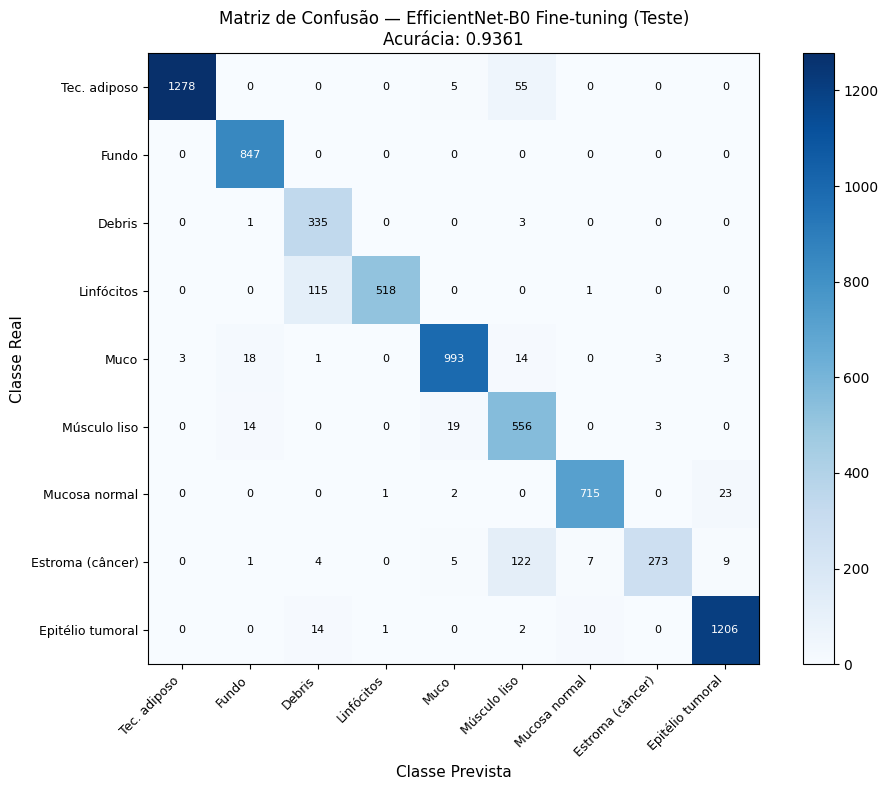


Matriz de confusão salva em 'matriz_confusao_teste.png'


In [10]:
# ============================================================
# ETAPA 5 — BLOCO 2: Avaliação no TESTE (única vez) + Matriz de Confusão
# ============================================================
!pip install scikit-learn -q
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASSES = ["Tec. adiposo", "Fundo", "Debris", "Linfócitos", "Muco",
           "Músculo liso", "Mucosa normal", "Estroma (câncer)", "Epitélio tumoral"]

# --- Coletar previsões no teste completo ---
todas_preds, todos_reais = [], []
modelo.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = torch.argmax(modelo(imgs), dim=1).cpu().numpy()
        todas_preds.extend(preds)
        todos_reais.extend(labels.numpy())

todas_preds = np.array(todas_preds)
todos_reais = np.array(todos_reais)

# --- Acurácia de generalização (a métrica final do trabalho) ---
acc_teste = accuracy_score(todos_reais, todas_preds)
print("="*55)
print(f"ACURÁCIA NO TESTE (generalização real): {acc_teste:.4f}")
print("="*55)

# --- Métricas por classe ---
print("\nMétricas por classe:")
print(classification_report(todos_reais, todas_preds, target_names=CLASSES, digits=3))

# --- Matriz de confusão 9x9 ---
cm = confusion_matrix(todos_reais, todas_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(9)); ax.set_yticks(range(9))
ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CLASSES, fontsize=9)
ax.set_xlabel("Classe Prevista", fontsize=11)
ax.set_ylabel("Classe Real", fontsize=11)
ax.set_title(f"Matriz de Confusão — EfficientNet-B0 Fine-tuning (Teste)\nAcurácia: {acc_teste:.4f}", fontsize=12)

# Escrever os números em cada célula
for i in range(9):
    for j in range(9):
        cor = "white" if cm[i, j] > cm.max()/2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=cor, fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("matriz_confusao_teste.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nMatriz de confusão salva em 'matriz_confusao_teste.png'")